# Stage 1 — EDA and Understanding the Experiment

**Project:** Causal ML for Personalized Advertising  
**Dataset:** Criteo Uplift Prediction Dataset v2.1 (unbiased release)

This notebook answers four questions:

1. What is one row, and what do the columns mean?
2. Does the randomized ad assignment increase visits or conversions on average?
3. Is treatment assignment balanced across observed pre-treatment features?
4. What can and cannot be claimed from this released benchmark?

> **Key distinction:** Predicting who will visit is not the same as estimating who will visit *because of an ad*. Stage 1 establishes the randomized-experiment baseline before any CATE model is trained.

## 1. Experiment and estimand

The official Criteo description says the data combine several **incrementality tests**. A randomized part of the population was prevented from being targeted by advertising.

- **Unit:** one user.
- **Randomized assignment / instrument:** treatment (1 = eligible for ad targeting; 0 = control).
- **Actual ad delivery:** exposure. This occurs after random assignment and is not itself randomized.
- **Outcomes:** visit and conversion.
- **Covariates:** f0–f11, anonymized continuous features transformed for privacy.

Our primary estimand is the **intention-to-treat (ITT) average treatment effect** on visit:

$$ATE_{ITT}=E[Y\mid Z=1]-E[Y\mid Z=0],$$

where $Z$ is treatment assignment. Under the documented randomization—and assuming the release/subsampling procedure preserves that randomized contrast—the raw difference in means is the ITT benchmark for the released experimental sample. It is not Criteo's historical production ATE. We use visit as the primary outcome because it is much less rare than conversion; conversion is an important secondary outcome.

**Important:** comparing exposed with unexposed users is descriptive, not a randomized causal comparison. Exposure depends on assignment and ad-delivery/user behavior, so conditioning on it can introduce selection bias.

Official source: https://ailab.criteo.com/criteo-uplift-prediction-dataset/

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python     :', platform.python_version())
print('Executable :', Path(sys.executable).name)
print('NumPy      :', np.__version__)
print('pandas     :', pd.__version__)
print('SciPy      :', scipy.__version__)


Python     : 3.10.19
Executable : python
NumPy      : 2.2.6
pandas     : 2.3.2
SciPy      : 1.15.3


## 2. Configuration

The CSV is about 3 GB, so reading it all into memory is unnecessary. We stream through it once:

- exact full-data counts, rates, moments, and missingness are accumulated by chunk;
- a deterministic random sample is retained only for visualizations;
- float32/int8 dtypes keep memory use modest.

On a typical laptop, the full scan should take roughly one to a few minutes. SAMPLE_TARGET controls plotting speed, not the accuracy of the ATE.

In [2]:
def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv from the current directory.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'

FEATURES = [f'f{i}' for i in range(12)]
BINARY_COLS = ['treatment', 'conversion', 'visit', 'exposure']
ALL_COLS = FEATURES + BINARY_COLS
DTYPES = {**{c: 'float32' for c in FEATURES}, **{c: 'int8' for c in BINARY_COLS}}

CHUNK_SIZE = 500_000
SAMPLE_TARGET = 200_000
RANDOM_SEED = 42

print(f'Data file: {DATA_PATH.relative_to(PROJECT_ROOT)}')
print(f'File size: {DATA_PATH.stat().st_size / 1024**3:.2f} GiB')


Data file: data/criteo-uplift-v2.1.csv
File size: 3.03 GiB


In [3]:
preview = pd.read_csv(DATA_PATH, nrows=5, dtype=DTYPES)
display(preview)
display(preview.dtypes.rename('dtype').to_frame())

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616364,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616364,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616364,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616364,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


,dtype
f0,float32
f1,float32
f2,float32
f3,float32
f4,float32
f5,float32
f6,float32
f7,float32
f8,float32
f9,float32


## 3. One full-data streaming pass

The next cell intentionally computes exact aggregate statistics over every row. It does not estimate the ATE from the plotting sample.

In [4]:
start_time = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)

n_total = 0
missing_counts = pd.Series(0, index=ALL_COLS, dtype='int64')
feature_min = pd.Series(np.inf, index=FEATURES, dtype='float64')
feature_max = pd.Series(-np.inf, index=FEATURES, dtype='float64')
binary_values = {c: set() for c in BINARY_COLS}
group_n = {0: 0, 1: 0}
group_feature_sum = {t: np.zeros(len(FEATURES), dtype='float64') for t in (0, 1)}
group_feature_sumsq = {t: np.zeros(len(FEATURES), dtype='float64') for t in (0, 1)}
group_outcome_sum = {t: {c: 0 for c in ['visit', 'conversion', 'exposure']} for t in (0, 1)}
treatment_exposure_counts = np.zeros((2, 2), dtype='int64')
conversion_without_visit = 0
sample_parts = []

# The official v2.1 row count is used only to set the plotting-sample probability.
# Exact n_total is still computed from the local file.
expected_rows = 13_979_592
sample_probability = min(1.0, SAMPLE_TARGET / expected_rows)

for chunk_number, chunk in enumerate(pd.read_csv(DATA_PATH, dtype=DTYPES, chunksize=CHUNK_SIZE), start=1):
    n = len(chunk)
    n_total += n
    missing_counts += chunk.isna().sum()
    feature_min = np.minimum(feature_min, chunk[FEATURES].min())
    feature_max = np.maximum(feature_max, chunk[FEATURES].max())
    conversion_without_visit += int(((chunk['conversion'] == 1) & (chunk['visit'] == 0)).sum())

    for col in BINARY_COLS:
        binary_values[col].update(chunk[col].unique().tolist())

    t_arr = chunk['treatment'].to_numpy()
    e_arr = chunk['exposure'].to_numpy()
    np.add.at(treatment_exposure_counts, (t_arr, e_arr), 1)

    for t in (0, 1):
        arm = chunk.loc[chunk['treatment'].eq(t)]
        X_arm = arm[FEATURES].to_numpy(dtype='float64')
        group_n[t] += len(arm)
        group_feature_sum[t] += X_arm.sum(axis=0)
        group_feature_sumsq[t] += np.square(X_arm).sum(axis=0)
        for outcome in ['visit', 'conversion', 'exposure']:
            group_outcome_sum[t][outcome] += int(arm[outcome].sum())

    keep = rng.random(n) < sample_probability
    sample_parts.append(chunk.loc[keep].copy())

sample = pd.concat(sample_parts, ignore_index=True)
elapsed = time.perf_counter() - start_time

print(f'Scanned {n_total:,} rows in {elapsed:,.1f} seconds.')
print(f'Retained {len(sample):,} rows ({len(sample)/n_total:.2%}) for plots.')


Scanned 13,979,592 rows in 14.9 seconds.
Retained 199,808 rows (1.43%) for plots.


## 4. Data quality and schema checks

These checks prevent silent errors before causal analysis: schema drift, missing values, non-binary flags, and impossible outcome orderings.

In [5]:
schema_checks = pd.DataFrame({
    'check': [
        'Expected columns present',
        'No missing values',
        'Binary columns contain only 0/1',
        'No conversion without visit',
    ],
    'passed': [
        list(preview.columns) == ALL_COLS,
        int(missing_counts.sum()) == 0,
        all(values.issubset({0, 1}) for values in binary_values.values()),
        conversion_without_visit == 0,
    ],
    'detail': [
        ', '.join(preview.columns),
        f'{int(missing_counts.sum()):,} missing cells',
        str({k: sorted(v) for k, v in binary_values.items()}),
        f'{conversion_without_visit:,} rows',
    ]
})
display(schema_checks)

feature_summary = pd.DataFrame({
    'min': feature_min,
    'max': feature_max,
})
display(feature_summary)


,check,passed,detail
0,Expected columns present,True,"f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f..."
1,No missing values,True,0 missing cells
2,Binary columns contain only 0/1,True,"{'treatment': [0, 1], 'conversion': [0, 1], 'v..."
3,No conversion without visit,True,0 rows


,min,max
f0,12.616364,26.745255
f1,10.059654,16.344187
f2,8.214383,9.051962
f3,-8.398387,4.679882
f4,10.280525,21.123508
f5,-9.011891,4.115453
f6,-31.429783,0.294443
f7,4.833815,11.998401
f8,3.635107,3.971858
f9,13.190056,75.295021


## 5. Sample size, allocation, and event rarity

In [6]:
arm_summary = pd.DataFrame({
    'n': pd.Series(group_n),
    'visit_events': pd.Series({t: group_outcome_sum[t]['visit'] for t in (0, 1)}),
    'conversion_events': pd.Series({t: group_outcome_sum[t]['conversion'] for t in (0, 1)}),
    'exposure_events': pd.Series({t: group_outcome_sum[t]['exposure'] for t in (0, 1)}),
})
arm_summary.index = arm_summary.index.map({0: 'control', 1: 'treatment'})
arm_summary['share'] = arm_summary['n'] / arm_summary['n'].sum()
arm_summary['visit_rate'] = arm_summary['visit_events'] / arm_summary['n']
arm_summary['conversion_rate'] = arm_summary['conversion_events'] / arm_summary['n']
arm_summary['exposure_rate'] = arm_summary['exposure_events'] / arm_summary['n']
display(arm_summary)

overall_rates = pd.Series({
    'visit_rate': arm_summary['visit_events'].sum() / n_total,
    'conversion_rate': arm_summary['conversion_events'].sum() / n_total,
    'treatment_share': arm_summary.loc['treatment', 'share'],
}, name='full_data')
display(overall_rates.to_frame())

,n,visit_events,conversion_events,exposure_events,share,visit_rate,conversion_rate,exposure_rate
control,2096937,80105,4063,0,0.150000,0.038201,0.001938,0.000000
treatment,11882655,576824,36711,428212,0.850000,0.048543,0.003089,0.036037


,full_data
visit_rate,0.046992
conversion_rate,0.002917
treatment_share,0.850000


**Why is treatment not 50/50?** Unequal randomization does not bias a difference-in-means estimator. It does mean the smaller control arm—especially its rare conversions—contributes more sampling variance. With millions of observations, precision is still high.

## 6. Randomization diagnostic: feature balance

For each feature, the standardized mean difference (SMD) is

$$SMD=\frac{\bar X_1-\bar X_0}{\sqrt{(s_1^2+s_0^2)/2}}.$$

SMD measures practical imbalance on a common scale. With nearly 14 million rows, classical t-tests can flag negligible differences, so magnitude matters more than p-values. A common observational-study rule of thumb is |SMD| < 0.1; a randomized experiment this large should usually be much tighter.

,control_mean,treatment_mean,pooled_sd,smd,abs_smd
f3,4.232821,4.169412,1.298404,-0.048836,0.048836
f6,-3.999880,-4.182792,4.522161,-0.040448,0.040448
f5,4.039339,4.026602,0.416808,-0.030557,0.030557
f9,15.886252,16.052589,6.930371,0.024001,0.024001
f1,10.067935,10.070336,0.100077,0.023994,0.023994
f8,3.934652,3.933392,0.056162,-0.022433,0.022433
f7,5.080284,5.105555,1.188131,0.021270,0.021270
f10,5.331898,5.333660,0.166774,0.010563,0.010563
f4,10.336526,10.339245,0.341410,0.007966,0.007966
f0,19.651705,19.614755,5.381842,-0.006866,0.006866


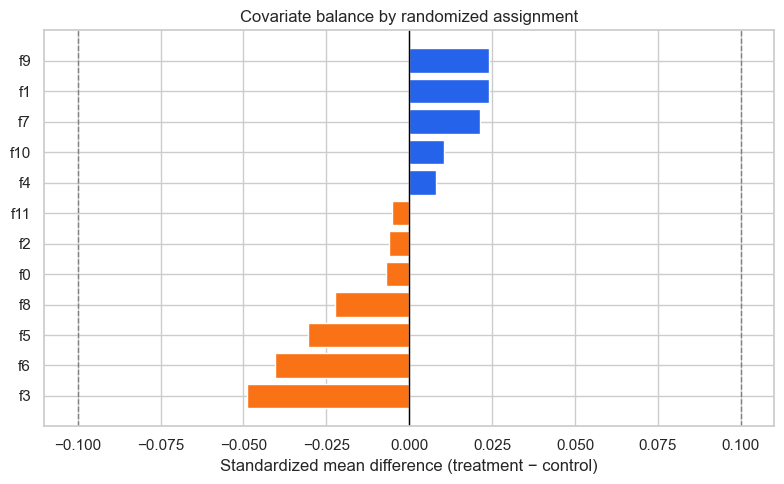

Maximum absolute SMD: 0.048836


In [7]:
means = {}
variances = {}
for t in (0, 1):
    means[t] = group_feature_sum[t] / group_n[t]
    variances[t] = (
        group_feature_sumsq[t] - (group_feature_sum[t] ** 2 / group_n[t])
    ) / (group_n[t] - 1)

pooled_sd = np.sqrt((variances[1] + variances[0]) / 2)
smd = np.divide(means[1] - means[0], pooled_sd, out=np.zeros_like(pooled_sd), where=pooled_sd > 0)

balance = pd.DataFrame({
    'control_mean': means[0],
    'treatment_mean': means[1],
    'pooled_sd': pooled_sd,
    'smd': smd,
    'abs_smd': np.abs(smd),
}, index=FEATURES).sort_values('abs_smd', ascending=False)
display(balance)

fig, ax = plt.subplots(figsize=(8, 5))
plot_balance = balance.sort_values('smd')
colors = np.where(plot_balance['smd'] >= 0, '#2563eb', '#f97316')
ax.barh(plot_balance.index, plot_balance['smd'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1)
ax.axvline(-0.1, color='gray', linestyle='--', linewidth=1)
ax.set(title='Covariate balance by randomized assignment', xlabel='Standardized mean difference (treatment − control)')
plt.tight_layout()
plt.show()

print(f'Maximum absolute SMD: {balance.abs_smd.max():.6f}')


**Interpretation:** no feature exceeds the conventional |SMD| = 0.1 warning threshold, but the maximum (~0.049) is not literally zero. Pooling several experiments and the official non-uniform release sampling can leave small compositional differences. This diagnostic does not prove randomization; the causal justification comes from the documented design. In later modeling, stratification and covariate-adjusted robustness checks are still worthwhile.

## 7. Feature distributions

The features are anonymized/randomly projected. We can assess scale, skew, tails, and near-constant behavior, but we cannot assign business meanings such as age or purchase history. The plot uses only the deterministic sample.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
f0,"199,808.000000",19.631416,5.380055,12.616364,12.616364,12.616364,12.616364,21.934016,24.468422,26.312722,26.674812,26.745163
f1,"199,808.000000",10.069960,0.108297,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.679513,14.390953
f2,"199,808.000000",8.447525,0.299648,8.214383,8.214383,8.214383,8.214383,8.214383,8.728073,9.004370,9.042862,9.051958
f3,"199,808.000000",4.182344,1.331527,-5.996527,-1.700105,0.973841,4.679882,4.679882,4.679882,4.679882,4.679882,4.679882
f4,"199,808.000000",10.338530,0.342873,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,11.973288,21.123508
f5,"199,808.000000",4.030257,0.428116,-6.293956,2.230907,3.013064,4.115453,4.115453,4.115453,4.115453,4.115453,4.115453
f6,"199,808.000000",-4.154446,4.571856,-29.467640,-17.777273,-13.353455,-6.699321,-2.411115,0.294443,0.294443,0.294443,0.294443
f7,"199,808.000000",5.094326,1.188774,4.833815,4.833815,4.833815,4.833815,4.833815,4.833815,5.668139,11.471979,11.998372
f8,"199,808.000000",3.933517,0.056643,3.650455,3.752416,3.806309,3.910792,3.971858,3.971858,3.971858,3.971858,3.971858
f9,"199,808.000000",16.025633,7.012401,13.190056,13.190056,13.190056,13.190056,13.190056,13.190056,33.712555,44.784328,67.231873


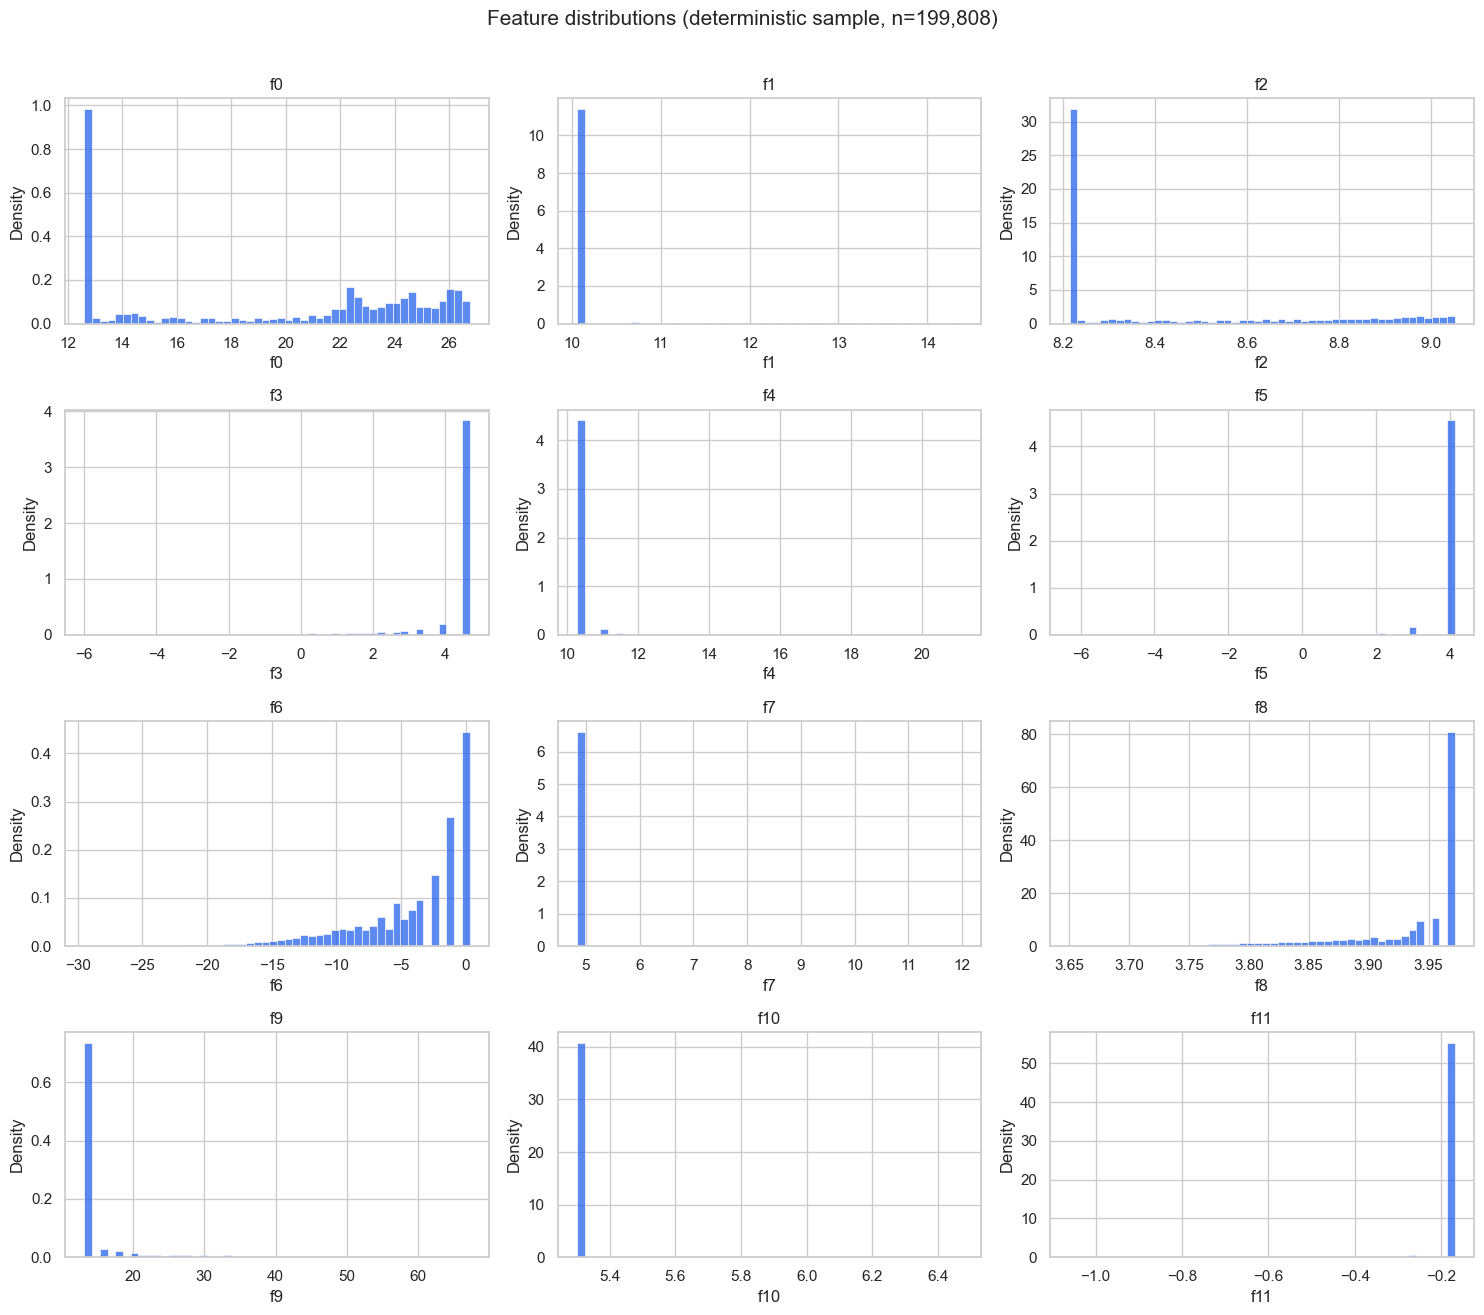

In [8]:
display(sample[FEATURES].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for feature, ax in zip(FEATURES, axes.flat):
    sns.histplot(sample[feature], bins=50, stat='density', color='#2563eb', alpha=0.75, ax=ax)
    ax.set_title(feature)
    ax.set_ylabel('Density')
fig.suptitle(f'Feature distributions (deterministic sample, n={len(sample):,})', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

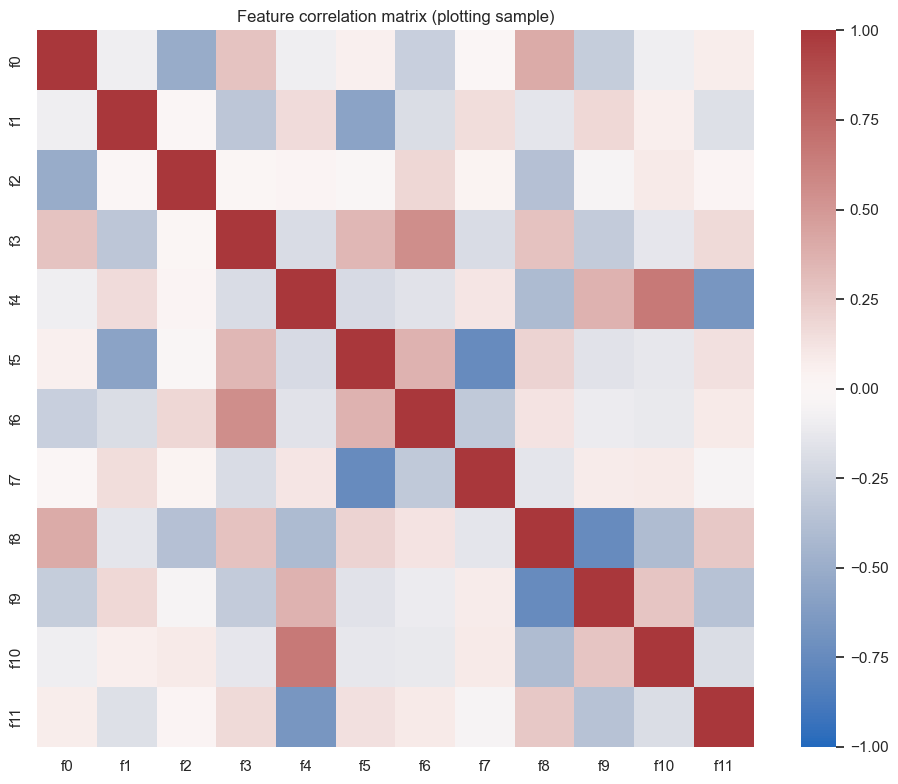

correlation
f8 f9     -0.749951
f5 f7     -0.742797
f4 f11    -0.670469
   f10     0.659524
f1 f5     -0.578104
f3 f6      0.547441
f0 f2     -0.513147
f4 f8     -0.409720
f0 f8      0.403495
f8 f10    -0.402688

In [9]:
corr = sample[FEATURES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature correlation matrix (plotting sample)')
plt.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_correlations = upper.reindex(upper.abs().sort_values(ascending=False).index).head(10)
display(top_correlations.rename('correlation').to_frame())

## 8. ITT effect estimates with 95% confidence intervals

For a binary outcome, the standard error of the unadjusted difference in proportions is

$$SE(\hat p_1-\hat p_0)=\sqrt{\frac{\hat p_1(1-\hat p_1)}{n_1}+\frac{\hat p_0(1-\hat p_0)}{n_0}}.$$

Because treatment assignment is randomized, no propensity-score adjustment is needed for identification. Later, covariate adjustment may improve precision, but should not replace this transparent benchmark.

In [10]:
def difference_in_proportions(outcome: str) -> dict:
    n1, n0 = group_n[1], group_n[0]
    p1 = group_outcome_sum[1][outcome] / n1
    p0 = group_outcome_sum[0][outcome] / n0
    diff = p1 - p0
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    z = diff / se
    log10_p_value = (np.log(2) + stats.norm.logsf(abs(z))) / np.log(10)
    p_value = 10 ** log10_p_value if log10_p_value > -300 else 0.0
    ci_low, ci_high = diff + np.array([-1, 1]) * stats.norm.ppf(0.975) * se
    return {
        'outcome': outcome,
        'control_rate': p0,
        'treatment_rate': p1,
        'ate_absolute': diff,
        'ate_percentage_points': 100 * diff,
        'relative_lift': diff / p0 if p0 else np.nan,
        'std_error': se,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'z_stat': z,
        'p_value': p_value,
        'log10_p_value': log10_p_value,
        'incremental_events_per_million_assignments': 1_000_000 * diff,
        'assignments_per_incremental_event': 1 / diff if diff > 0 else np.nan,
    }

effect_results = pd.DataFrame([
    difference_in_proportions('visit'),
    difference_in_proportions('conversion'),
]).set_index('outcome')
display(effect_results)

for outcome, row in effect_results.iterrows():
    p_text = (
        f'p={row.p_value:.3g}'
        if row.log10_p_value > -300
        else f'p < 1e-300 (log10 p = {row.log10_p_value:.1f})'
    )
    print(
        f'{outcome.capitalize():10s}: {row.ate_percentage_points:+.4f} percentage points '
        f'(95% CI {100*row.ci_95_low:+.4f}, {100*row.ci_95_high:+.4f}); '
        f'relative lift {row.relative_lift:+.1%}; {p_text}'
    )


,control_rate,treatment_rate,ate_absolute,ate_percentage_points,relative_lift,std_error,ci_95_low,ci_95_high,z_stat,p_value,log10_p_value,incremental_events_per_million_assignments,assignments_per_incremental_event
outcome,,,,,,,,,,,,,
visit,0.038201,0.048543,0.010342,1.034240,0.270737,0.000146,0.010056,0.010629,70.685184,0.000000,"-1,086.900913","10,342.403129",96.689327
conversion,0.001938,0.003089,0.001152,0.115187,0.594488,0.000034,0.001085,0.001219,33.512267,0.000000,-245.495651,"1,151.873052",868.151224


Visit     : +1.0342 percentage points (95% CI +1.0056, +1.0629); relative lift +27.1%; p < 1e-300 (log10 p = -1086.9)
Conversion: +0.1152 percentage points (95% CI +0.1085, +0.1219); relative lift +59.4%; p=3.19e-246


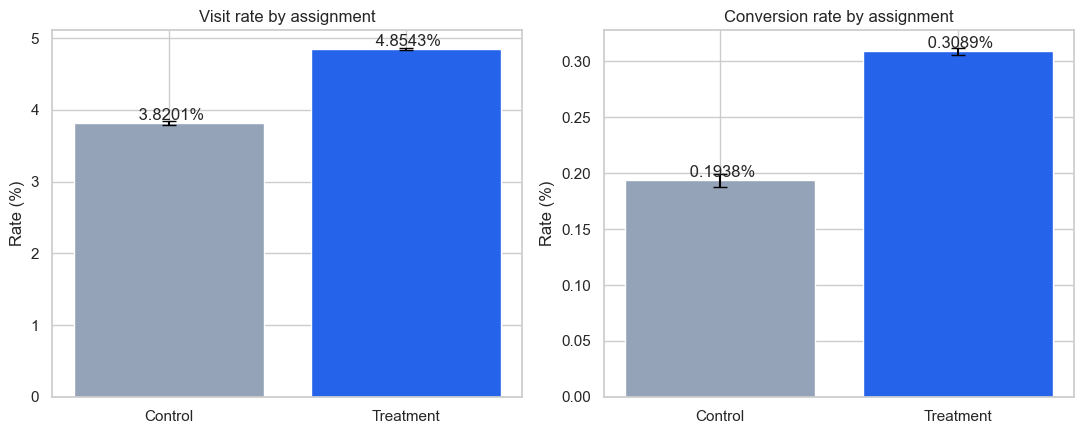

In [11]:
plot_rows = []
for outcome in ['visit', 'conversion']:
    for t, arm_name in [(0, 'Control'), (1, 'Treatment')]:
        n = group_n[t]
        p = group_outcome_sum[t][outcome] / n
        se = np.sqrt(p * (1 - p) / n)
        plot_rows.append({'outcome': outcome, 'arm': arm_name, 'rate': p, 'ci': 1.96 * se})
rate_plot = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, outcome in zip(axes, ['visit', 'conversion']):
    d = rate_plot.query('outcome == @outcome')
    ax.bar(d['arm'], 100 * d['rate'], color=['#94a3b8', '#2563eb'])
    ax.errorbar(d['arm'], 100 * d['rate'], yerr=100 * d['ci'], fmt='none', color='black', capsize=5)
    ax.set_title(f'{outcome.capitalize()} rate by assignment')
    ax.set_ylabel('Rate (%)')
    for x, value in enumerate(100 * d['rate']):
        ax.text(x, value, f' {value:.4f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [12]:
visit = effect_results.loc['visit']
conversion = effect_results.loc['conversion']

display(Markdown(f'''### Business translation of the randomized effects

- **Visit ITT:** assignment to advertising increased visit probability by **{visit.ate_percentage_points:.3f} percentage points** (95% CI {100*visit.ci_95_low:.3f} to {100*visit.ci_95_high:.3f}). Relative to control, that is **{visit.relative_lift:.1%}**.
- At this experimental mix, that corresponds to about **{visit.incremental_events_per_million_assignments:,.0f} incremental visits per 1 million users assigned to treatment**, or roughly one incremental visit per **{visit.assignments_per_incremental_event:,.0f} assignments**.
- **Conversion ITT:** assignment increased conversion probability by **{conversion.ate_percentage_points:.3f} percentage points** (95% CI {100*conversion.ci_95_low:.3f} to {100*conversion.ci_95_high:.3f}), a **{conversion.relative_lift:.1%}** relative lift.
- Statistical significance is not the business decision. Profitability still requires impression cost, conversion value, and an allocation constraint—none are included in this dataset.
'''))

### Business translation of the randomized effects

- **Visit ITT:** assignment to advertising increased visit probability by **1.034 percentage points** (95% CI 1.006 to 1.063). Relative to control, that is **27.1%**.
- At this experimental mix, that corresponds to about **10,342 incremental visits per 1 million users assigned to treatment**, or roughly one incremental visit per **97 assignments**.
- **Conversion ITT:** assignment increased conversion probability by **0.115 percentage points** (95% CI 0.108 to 0.122), a **59.4%** relative lift.
- Statistical significance is not the business decision. Profitability still requires impression cost, conversion value, and an allocation constraint—none are included in this dataset.


## 9. Assignment versus actual exposure

This table tests **one-sided compliance**: control users should not be exposed. The treatment arm includes many users who were eligible/targetable but did not actually receive an impression.

In [13]:
treatment_exposure_table = pd.DataFrame(
    treatment_exposure_counts,
    index=pd.Index(['control', 'treatment'], name='assignment'),
    columns=pd.Index(['not_exposed', 'exposed'], name='actual_exposure')
)
display(treatment_exposure_table)

first_stage = (
    treatment_exposure_table.loc['treatment', 'exposed'] / treatment_exposure_table.loc['treatment'].sum()
    - treatment_exposure_table.loc['control', 'exposed'] / treatment_exposure_table.loc['control'].sum()
)
print(f'First stage: assignment increases actual exposure by {100*first_stage:.4f} percentage points.')

exposure_descriptive = sample.groupby('exposure')[['visit', 'conversion']].agg(['count', 'mean'])
display(exposure_descriptive)
print('CAUTION: the exposed-vs-unexposed outcome gap above is descriptive, not a causal ATE.')

actual_exposure,not_exposed,exposed
assignment,,
control,2096937,0
treatment,11454443,428212


First stage: assignment increases actual exposure by 3.6037 percentage points.


visit          conversion         
           count     mean      count     mean
exposure                                     
0         193866 0.035267     193866 0.001300
1           5942 0.416022       5942 0.053012

CAUTION: the exposed-vs-unexposed outcome gap above is descriptive, not a causal ATE.


### Why not use exposure as treatment?

A compact causal picture is:

$$Z\;\text{(random assignment)} \rightarrow D\;\text{(actual exposure)} \rightarrow Y.$$

User/ad-delivery factors can affect both $D$ and $Y$. Therefore $E[Y\mid D=1]-E[Y\mid D=0]$ mixes the ad effect with selection. Using assignment $Z$ estimates ITT. Estimating the effect of actual exposure among compliers would require an instrumental-variable argument and assumptions such as exclusion, relevance, monotonicity, and random assignment. That is a later extension, not the Stage 1 headline.

## 10. What the EDA establishes—and what it does not

### Supported conclusions

- The local file matches the v2.1 schema and contains the full released sample.
- No observed covariate shows severe imbalance by the conventional |SMD| = 0.1 rule (maximum ~0.049), though the arms are not literally identical.
- The unadjusted treatment-control gap is the correct transparent ITT benchmark.
- Visit supplies many more positive examples than conversion, making it the more stable first outcome for later uplift modeling.
- Exposure is a post-assignment variable and should not enter a targeting model as a pre-treatment feature.

### Limitations

- Criteo pooled several incrementality tests; campaign/advertiser IDs are unavailable.
- The official release was non-uniformly subsampled and transformed for privacy. The released-sample ATE is useful for benchmarking, but it should not be presented as Criteo's historical production incrementality.
- Features are anonymous, limiting mechanism interpretation and actionable segment naming.
- No impression cost, revenue, frequency, or time fields are available, so ROI and long-run effects cannot be identified.
- EDA and ATE establish an average effect, not treatment-effect heterogeneity. CATE claims need honest holdout evaluation in later stages.

## 11. Methodological notes

- Because treatment is randomized assignment, the difference in arm means identifies the intent-to-treat effect for the released experimental sample.
- Unequal 85/15 allocation affects precision rather than unbiasedness; the smaller control arm is the variance bottleneck.
- A high-AUC response model ranks likely visitors, whereas targeting requires the counterfactual contrast $E[Y(1)-Y(0)\mid X]$.
- Visit is the primary modeling outcome because conversion is much rarer and produces higher-variance subgroup estimates. Conversion remains a secondary business outcome.
- `exposure` is excluded because it occurs after assignment, is unavailable at targeting time, and can introduce post-treatment selection bias.
- Statistical significance alone is insufficient at this scale. Absolute effects, confidence intervals, incremental events, and unit economics are all needed for a decision.

The next step is to build a response-prediction baseline, then compare it with treatment-effect models using randomized policy value and ranking metrics.

## 12. Stage 1 takeaway

The experiment supports a positive average causal effect of ad assignment on both outcomes in the released benchmark. The most important modeling insight is that this ATE is only a population average: it does not reveal which users are persuadable. The rest of the project should preserve the randomized treatment definition, exclude post-treatment exposure from targeting features, and evaluate whether CATE rankings improve constrained ad allocation beyond response prediction and random targeting.